In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import os

from langchain_core.documents import Document
from tqdm import tqdm

from missing_citation_retriever.missing_citation_retriever import MissingCitationRetriever

%load_ext autoreload
%autoreload 2

# disable logging
import logging
logging.disable(logging.CRITICAL)

# Indexing papers to recommend

In [2]:
DATASET_PATH = "C:\\Users\\Adrian\\Documents\\datasets\\peerread"
CLASSIFIER_PATH = "C:\\Users\\Adrian\\Documents\\models\\citing_sentence_classifier"

In [3]:
papers_df = pd.read_json(os.path.join(DATASET_PATH, "papers.json"), orient="index")

papers_df.head()

,id,authors,abstract,year,title,venue
1606.03622v1,1606.03622v1,"[robin jia, percy liang]",Modeling crisp logical regularities is crucial...,2016,Data Recombination for Neural Semantic Parsing,ACL
1511.00360v1,1511.00360v1,"[chuang ding, lei xie, jie yan, weini zhang, y...",Prosody affects the naturalness and intelligib...,2015,Automatic Prosody Prediction for Chinese Speec...,arxiv
1705.10900v1,1705.10900v1,"[paul michel, abhilasha ravichander, shruti ri...",We investigate the pertinence of methods from ...,2017,Does the Geometry of Word Embeddings Help Docu...,arxiv
1709.00845v1,1709.00845v1,"[andre s yoon, taehoon lee, yongsub lim, deokw...",This work presents a novel semi-supervised lea...,2017,Semi-supervised Learning with Deep Generative ...,arxiv
1511.06295v1,1511.06295v1,"[andrei a rusu, sergio gomez colmenarejo, cagl...",Policies for complex visual tasks have been su...,2015,Policy Distillation,iclr


In [4]:
retriever = MissingCitationRetriever(paper_index='test_papers',
                                     embeddings_index='test_embeddings',
                                     citing_sentence_classifier_path=CLASSIFIER_PATH,
                                     silent=True,
                                     k=100)

In [ ]:
# index in batches of 256
for i in range(0, len(papers_df), 256):
    print(f"Indexing papers {i} to {i + 256}")

    retriever.index_papers(papers_df['title'][i:i + 256],
                           papers_df['abstract'][i:i + 256])


In [7]:
citation_df = pd.read_json(os.path.join(DATASET_PATH, "contexts.json"), orient="index")

citation_df.head()

,citing_id,refid,masked_text
1606.03622v1_1409.3215v1_0,1606.03622v1,1409.3215v1,"software,requiring hand-crafted features, lexi..."
1606.03622v1_1412.7449v1_0,1606.03622v1,1412.7449v1,"nd-crafted features, lexicons, and grammars.Me..."
1606.03622v1_1506.03134v1_0,1606.03622v1,1506.03134v1,"aining, we maximize the log-likelihood of y,ma..."
1511.00360v1_1310.4546v1_0,1511.00360v1,1310.4546v1,"feature, in form of a low dimensionalcontinuo..."
1705.10900v1_1310.4546v1_0,1705.10900v1,1310.4546v1,esentations in the case of sentiment and topic...


# Evaluation

We will calculate recall at different k values for citation recommendation.
Recall@k measures the proportion of relevant citations that appear in the top-k recommended papers.

In [8]:
def calculate_recall_at_k(true_citations, predicted_citations, k):
    true_set = set(true_citations)
    pred_set = set(predicted_citations[:k])
    if len(true_set) == 0:
        return 0.0
    return len(true_set.intersection(pred_set)) / len(true_set)


ks = [1, 5, 10, 25, 30, 50, 80, 100]
ns = [1, 5, 10]
recalls = []
post_rerank_recalls = []
no_help_rerank_recalls = []

for index, row in tqdm(citation_df.iterrows(), total=citation_df[:1].shape[0]):
    fake_state = {'sentence': row['masked_text']}
    # Retrieve candidates
    docs = retriever._retrieve(fake_state)['retrieved']
    candidates = [paper.metadata['title'] for paper in docs]
    candidate_ids = [papers_df.loc[papers_df['title'] == paper]['id'].iloc[0] for paper in candidates]

    true_citation = [row['refid']]
    recalls_at_k = [calculate_recall_at_k(true_citation, candidate_ids, k) for k in ks]
    recalls.append(recalls_at_k)
    # Print the results for this row
    docs = docs[:25]  # Limit to top 25 candidates for reranking
    # Insert the true citation into the state for reranking
    if true_citation[0] not in candidate_ids[:25]:
        no_help_rerank_recalls.append([calculate_recall_at_k(true_citation, candidate_ids, n) for n in ns])

        # If the true citation is not in the candidates, we add it to the retrieved documents
        doc = papers_df[papers_df['id'] == true_citation[0]].iloc[0]
        docs += [Document(page_content=doc['title'] + '\n\n' + doc['abstract'],
                                       metadata={'title': doc['title']})]

    fake_state['retrieved'] = docs
    # Rerank candidates
    reranked_candidates = retriever._reorder(fake_state)['reordered']
    reranked_candidate_ids = [papers_df.loc[papers_df['title'] == paper]['id'].iloc[0] for paper in reranked_candidates]

    post_rerank_recalls_at_n = [calculate_recall_at_k(true_citation, reranked_candidate_ids, n) for n in ns]
    post_rerank_recalls.append(post_rerank_recalls_at_n)

    if len(post_rerank_recalls) > len(no_help_rerank_recalls):
        no_help_rerank_recalls.append(post_rerank_recalls_at_n)


avg_recalls = pd.DataFrame(recalls, columns=[f'recall@{k}' for k in ks]).mean()
post_rerank_avg_recalls = pd.DataFrame(post_rerank_recalls, columns=[f'post_rerank_recall@{n}' for n in ns]).mean()
no_help_rerank_avg_recalls = pd.DataFrame(no_help_rerank_recalls, columns=[f'no_help_rerank_recall@{n}' for n in ns]).mean()

100%|██████████| 1/1 [00:02<00:00,  2.30s/it]
2it [00:05,  2.75s/it]                       
100%|██████████| 1/1 [00:02<00:00,  2.60s/it]
3it [00:08,  2.86s/it]
100%|██████████| 1/1 [00:02<00:00,  2.55s/it]
4it [00:11,  2.87s/it]
100%|██████████| 1/1 [00:02<00:00,  2.51s/it]
5it [00:14,  2.86s/it]
100%|██████████| 1/1 [00:02<00:00,  2.42s/it]
6it [00:17,  2.84s/it]
100%|██████████| 1/1 [00:02<00:00,  2.38s/it]
7it [00:19,  2.80s/it]
100%|██████████| 1/1 [00:02<00:00,  2.37s/it]
8it [00:22,  2.79s/it]
100%|██████████| 1/1 [00:02<00:00,  2.47s/it]
9it [00:25,  2.83s/it]
100%|██████████| 1/1 [00:02<00:00,  2.49s/it]
10it [00:28,  2.85s/it]
100%|██████████| 1/1 [00:02<00:00,  2.10s/it]
11it [00:30,  2.76s/it]
100%|██████████| 1/1 [00:02<00:00,  2.45s/it]
12it [00:33,  2.78s/it]
100%|██████████| 1/1 [00:02<00:00,  2.40s/it]
13it [00:36,  2.73s/it]
100%|██████████| 1/1 [00:02<00:00,  2.27s/it]
14it [00:38,  2.67s/it]
100%|██████████| 1/1 [00:02<00:00,  2.25s/it]
15it [00:41,  2.65s/it]
100%|

In [9]:
# Print results
print("Average Recall@k:")
for k, recall in zip(ks, avg_recalls):
    print(f"Recall@{k}: {recall:.4f}")

print("\nAverage Post-Rerank Recall@k:")
for k, recall in zip(ns, post_rerank_avg_recalls):
    print(f"Post-Rerank Recall@{k}: {recall:.4f}")

print("\nAverage No Help Rerank Recall@k:")
for n, recall in zip(ns, no_help_rerank_avg_recalls):
    print(f"No Help Rerank Recall@{n}: {recall:.4f}")


Average Recall@k:
Recall@1: 0.0855
Recall@5: 0.2035
Recall@10: 0.2730
Recall@25: 0.3717
Recall@30: 0.3933
Recall@50: 0.4558
Recall@80: 0.5152
Recall@100: 0.5460

Average Post-Rerank Recall@k:
Post-Rerank Recall@1: 0.3367
Post-Rerank Recall@5: 0.4882
Post-Rerank Recall@10: 0.6025

Average No Help Rerank Recall@k:
No Help Rerank Recall@1: 0.1810
No Help Rerank Recall@5: 0.2707
No Help Rerank Recall@10: 0.3268


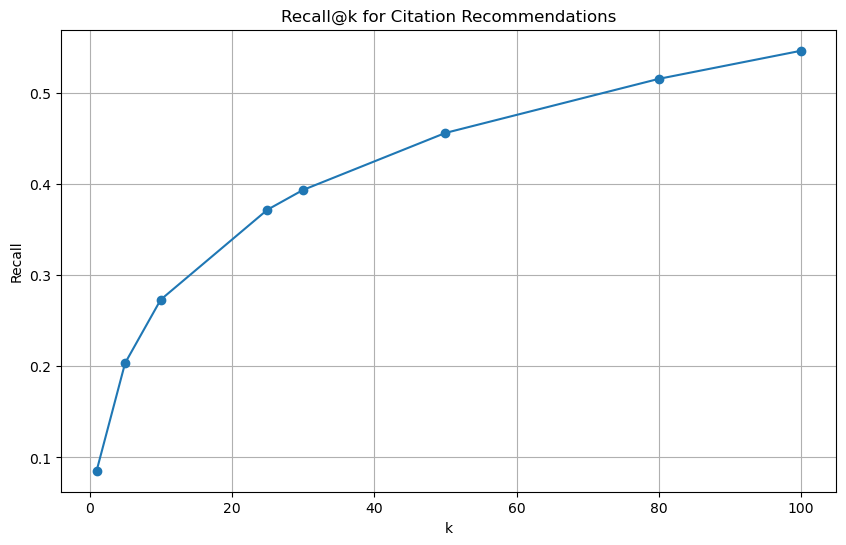

In [10]:
# Visualize results
plt.figure(figsize=(10, 6))
plt.plot(ks, avg_recalls, marker='o')
plt.title('Recall@k for Citation Recommendations')
plt.xlabel('k')
plt.ylabel('Recall')
plt.grid(True)
plt.show()


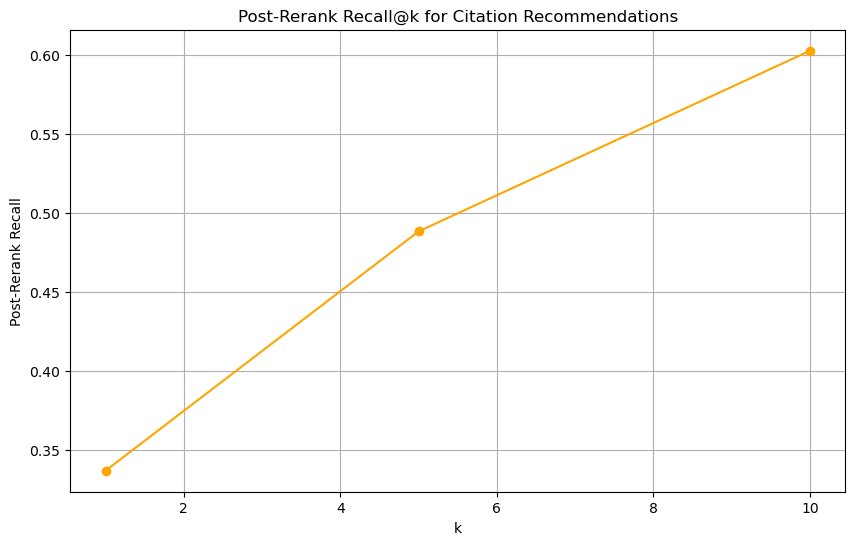

In [11]:
# Visualize post-rerank results
plt.figure(figsize=(10, 6))
plt.plot(ns, post_rerank_avg_recalls, marker='o', color='orange')
plt.title('Post-Rerank Recall@k for Citation Recommendations')
plt.xlabel('k')
plt.ylabel('Post-Rerank Recall')
plt.grid(True)
plt.show()

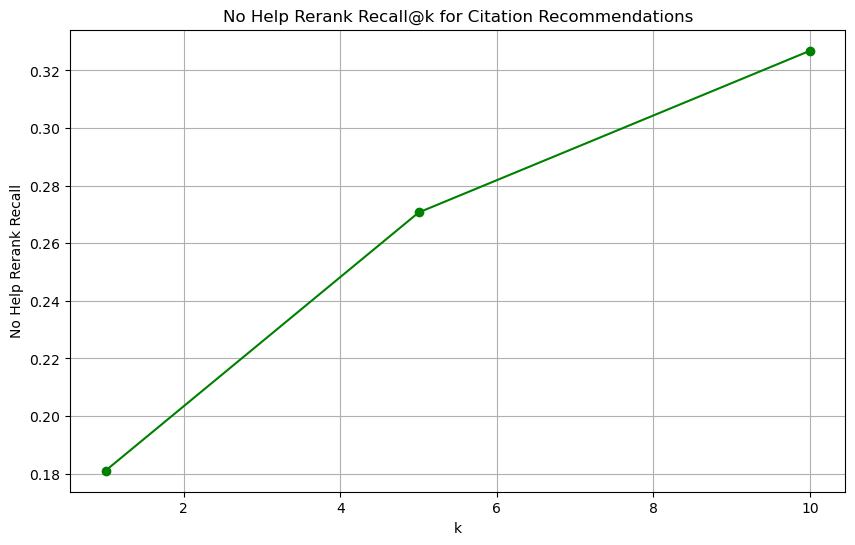

In [12]:
# Visualize no help rerank results
plt.figure(figsize=(10, 6))
plt.plot(ns, no_help_rerank_avg_recalls, marker='o', color='green')
plt.title('No Help Rerank Recall@k for Citation Recommendations')
plt.xlabel('k')
plt.ylabel('No Help Rerank Recall')
plt.grid(True)
plt.show()


In [13]:
 # pickle results
import pickle

with open('../data/paper_retrieval_results/recall_results.pkl', 'wb') as f:
    pickle.dump({
        'avg_recalls': avg_recalls,
        'post_rerank_avg_recalls': post_rerank_avg_recalls,
        'no_help_rerank_avg_recalls': no_help_rerank_avg_recalls
    }, f)